# 01 — Ingest

Load the Strava bulk export, filter to runs with HR + Relative Effort, parse per-second sensor streams from `.fit(.gz)` and `.gpx(.gz)` files transparently, and write two parquet artifacts:

- `data/raw/activities_raw.parquet` — one row per kept run (summary).
- `data/streams/streams.parquet` — long-format per-second sensor data.

Run from a kernel using the project's `.venv`.

In [1]:
import gzip
import math
import xml.etree.ElementTree as ET
from pathlib import Path

import numpy as np
import pandas as pd
from fitparse import FitFile
from tqdm.auto import tqdm

PROJECT_ROOT = Path.cwd()
assert PROJECT_ROOT.name == "Project", f"Run from Project/, not {PROJECT_ROOT}"

REPO_ROOT = PROJECT_ROOT.parent
EXPORT_ROOT = REPO_ROOT.parent / "Strava-Export"
ACT_DIR = EXPORT_ROOT / "activities"
DATA_DIR = PROJECT_ROOT / "data"

(DATA_DIR / "raw").mkdir(parents=True, exist_ok=True)
(DATA_DIR / "streams").mkdir(parents=True, exist_ok=True)

assert EXPORT_ROOT.exists(), f"Strava export not found at {EXPORT_ROOT}"
assert (EXPORT_ROOT / "activities.csv").exists()
print("Export root:", EXPORT_ROOT)
print("Activities dir files:", sum(1 for _ in ACT_DIR.iterdir()))

Export root: /Users/as/Library/Mobile Documents/com~apple~CloudDocs/Dokumente/Studium/Master-26-FS/Big Data Methods for Economists/Strava-Export
Activities dir files: 747


## 1.1 Load and clean the activity summary

`activities.csv` has duplicated columns where Strava re-emits the same field with a numeric suffix (`Distance3`, `Elapsed Time2`, `Max Heart Rate4`, `Relative Effort5`). Coalesce each pair to one canonical name.

In [2]:
activities = pd.read_csv(EXPORT_ROOT / "activities.csv", low_memory=False)
print("Raw shape:", activities.shape)

DUPLICATE_COALESCE = {
    "Elapsed Time": "Elapsed Time2",
    "Distance": "Distance3",
    "Max Heart Rate": "Max Heart Rate4",
    "Relative Effort": "Relative Effort5",
}
for canonical, alt in DUPLICATE_COALESCE.items():
    if alt in activities.columns:
        activities[canonical] = pd.to_numeric(
            activities[canonical], errors="coerce"
        ).combine_first(pd.to_numeric(activities[alt], errors="coerce"))
        activities = activities.drop(columns=[alt])

activities["Activity Date"] = pd.to_datetime(
    activities["Activity Date"], errors="coerce", utc=True
)
activities["date"] = activities["Activity Date"].dt.date
activities = activities.rename(columns={"Activity ID": "activity_id"})
activities["activity_id"] = activities["activity_id"].astype("int64")
print("Cleaned shape:", activities.shape)

Raw shape: (750, 101)
Cleaned shape: (750, 98)


/var/folders/q9/d95wjtz97h5dptsf6gjsbvdc0000gn/T/ipykernel_83412/3453285023.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  activities["Activity Date"] = pd.to_datetime(


## 1.2 Filter to runs with HR and Relative Effort

The target is Strava `Relative Effort`, and HR is needed to derive zone-based features in notebook 02.

In [3]:
runs = activities[activities["Activity Type"] == "Run"].copy()
print("Runs:", len(runs))

runs = runs.dropna(subset=["Average Heart Rate", "Relative Effort"])
runs = runs.drop_duplicates(subset=["activity_id"]).sort_values("Activity Date")
print("Runs with HR + Relative Effort:", len(runs))

# Resolve filenames (e.g. 'activities/9262906979.gpx.gz') against EXPORT_ROOT
runs["abs_path"] = runs["Filename"].apply(
    lambda f: (EXPORT_ROOT / f) if isinstance(f, str) else None
)
missing = runs[~runs["abs_path"].apply(lambda p: p is not None and p.exists())]
print("Missing files:", len(missing))
if len(missing):
    display(missing[["activity_id", "Filename"]].head())
runs = runs[runs["abs_path"].apply(lambda p: p is not None and p.exists())].reset_index(drop=True)
print("Final kept:", len(runs))

Runs: 604
Runs with HR + Relative Effort: 482
Missing files: 0
Final kept: 482


## 1.3 Transparent file readers

Most files are gzipped (`.fit.gz`, `.gpx.gz`). `gzip.open` decompresses on the fly so we don't have to extract anything to disk. FIT files give per-second HR/cadence/power; GPX from Strava strips those and only keeps lat/lon/ele/time.

In [4]:
SEMICIRCLE_TO_DEG = 180.0 / 2**31

STREAM_COLS = [
    "activity_id", "t", "elapsed_s",
    "lat", "lon", "ele_m", "dist_m", "speed_mps",
    "hr_bpm", "cadence_rpm", "power_w", "temp_c",
    "source_format",
]


def open_maybe_gz(p: Path):
    return gzip.open(p, "rb") if p.suffix == ".gz" else open(p, "rb")


def file_kind(p: Path) -> str:
    """Return 'fit' or 'gpx' regardless of .gz suffix."""
    stem = p.name.lower().replace(".gz", "")
    if stem.endswith(".fit"):
        return "fit"
    if stem.endswith(".gpx"):
        return "gpx"
    return "unknown"


def parse_fit(path: Path, activity_id: int) -> pd.DataFrame:
    with open_maybe_gz(path) as fh:
        fit = FitFile(fh.read())
    rows = []
    for msg in fit.get_messages("record"):
        d = {f.name: f.value for f in msg}
        ts = d.get("timestamp")
        if ts is None:
            continue
        lat = d.get("position_lat")
        lon = d.get("position_long")
        cad = d.get("cadence")
        frac = d.get("fractional_cadence")
        cadence = None
        if cad is not None:
            # Running cadence in spm = (cadence + fractional_cadence) * 2
            cadence = (cad + (frac or 0)) * 2
        rows.append({
            "t": ts,
            "lat": lat * SEMICIRCLE_TO_DEG if lat is not None else np.nan,
            "lon": lon * SEMICIRCLE_TO_DEG if lon is not None else np.nan,
            "ele_m": d.get("enhanced_altitude") if d.get("enhanced_altitude") is not None else d.get("altitude"),
            "dist_m": d.get("distance"),
            "speed_mps": d.get("enhanced_speed") if d.get("enhanced_speed") is not None else d.get("speed"),
            "hr_bpm": d.get("heart_rate"),
            "cadence_rpm": cadence,
            "power_w": d.get("power"),
            "temp_c": d.get("temperature"),
        })
    if not rows:
        return pd.DataFrame(columns=STREAM_COLS)
    df = pd.DataFrame(rows)
    df["t"] = pd.to_datetime(df["t"], utc=True, errors="coerce")
    df = df.dropna(subset=["t"]).sort_values("t").reset_index(drop=True)
    df["elapsed_s"] = (df["t"] - df["t"].iloc[0]).dt.total_seconds().astype("float32")
    df["activity_id"] = activity_id
    df["source_format"] = "fit"
    return df.reindex(columns=STREAM_COLS)


def _haversine_step(lat1, lon1, lat2, lon2):
    """Great-circle distance for consecutive trackpoints, in metres."""
    R = 6371000.0
    lat1, lat2 = np.radians(lat1), np.radians(lat2)
    dlat = lat2 - lat1
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


def parse_gpx(path: Path, activity_id: int) -> pd.DataFrame:
    with open_maybe_gz(path) as fh:
        tree = ET.parse(fh)
    root = tree.getroot()
    ns = {"g": root.tag.split("}")[0].strip("{")} if "}" in root.tag else {}
    pts = root.findall(".//g:trkpt", ns) if ns else root.findall(".//trkpt")

    rows = []
    for pt in pts:
        lat = float(pt.get("lat")) if pt.get("lat") else np.nan
        lon = float(pt.get("lon")) if pt.get("lon") else np.nan
        ele_el = pt.find("g:ele", ns) if ns else pt.find("ele")
        time_el = pt.find("g:time", ns) if ns else pt.find("time")
        rows.append({
            "t": time_el.text if time_el is not None else None,
            "lat": lat,
            "lon": lon,
            "ele_m": float(ele_el.text) if ele_el is not None and ele_el.text else np.nan,
        })
    if not rows:
        return pd.DataFrame(columns=STREAM_COLS)
    df = pd.DataFrame(rows)
    df["t"] = pd.to_datetime(df["t"], utc=True, errors="coerce")
    df = df.dropna(subset=["t"]).sort_values("t").reset_index(drop=True)

    # Derive cumulative distance (m) and step speed (m/s) via haversine
    if len(df) > 1:
        d_step = _haversine_step(
            df["lat"].shift().to_numpy(), df["lon"].shift().to_numpy(),
            df["lat"].to_numpy(), df["lon"].to_numpy(),
        )
        d_step = np.nan_to_num(d_step, nan=0.0)
        df["dist_m"] = np.cumsum(d_step)
        dt = df["t"].diff().dt.total_seconds().to_numpy()
        with np.errstate(divide="ignore", invalid="ignore"):
            df["speed_mps"] = np.where(dt > 0, d_step / dt, np.nan)
    else:
        df["dist_m"] = np.nan
        df["speed_mps"] = np.nan

    df["elapsed_s"] = (df["t"] - df["t"].iloc[0]).dt.total_seconds().astype("float32")
    df["hr_bpm"] = np.nan
    df["cadence_rpm"] = np.nan
    df["power_w"] = np.nan
    df["temp_c"] = np.nan
    df["activity_id"] = activity_id
    df["source_format"] = "gpx"
    return df.reindex(columns=STREAM_COLS)

## 1.4 Parse all kept activities

Loop the ~480 kept rows; dispatch by file kind; concatenate streams.

In [5]:
parsed = []
errors = []
for row in tqdm(runs.itertuples(index=False), total=len(runs), desc="Parsing"):
    aid = int(row.activity_id)
    p = row.abs_path
    kind = file_kind(p)
    try:
        if kind == "fit":
            df = parse_fit(p, aid)
        elif kind == "gpx":
            df = parse_gpx(p, aid)
        else:
            errors.append((aid, str(p), f"unknown kind: {p.name}"))
            continue
        if not df.empty:
            parsed.append(df)
    except Exception as e:
        errors.append((aid, str(p), repr(e)))

print(f"Parsed {len(parsed)} non-empty streams, {len(errors)} errors")
if errors:
    display(pd.DataFrame(errors, columns=["activity_id", "path", "error"]).head())

Parsing:   0%|          | 0/482 [00:00<?, ?it/s]

Parsed 482 non-empty streams, 0 errors


In [6]:
streams = pd.concat(parsed, ignore_index=True)

# Enforce dtypes for compact parquet
streams["activity_id"] = streams["activity_id"].astype("int64")
streams["lat"] = streams["lat"].astype("float64")
streams["lon"] = streams["lon"].astype("float64")
for c in ["elapsed_s", "ele_m", "dist_m", "speed_mps", "hr_bpm", "cadence_rpm", "power_w", "temp_c"]:
    streams[c] = pd.to_numeric(streams[c], errors="coerce").astype("float32")
streams["source_format"] = streams["source_format"].astype("category")
print("Stream rows:", len(streams))
print(streams.dtypes)
streams.head()

Stream rows: 1348656
activity_id                    int64
t                datetime64[us, UTC]
elapsed_s                    float32
lat                          float64
lon                          float64
ele_m                        float32
dist_m                       float32
speed_mps                    float32
hr_bpm                       float32
cadence_rpm                  float32
power_w                      float32
temp_c                       float32
source_format               category
dtype: object


,activity_id,t,elapsed_s,lat,lon,ele_m,dist_m,speed_mps,hr_bpm,cadence_rpm,power_w,temp_c,source_format
0,9271509294,2020-01-17 11:28:15+00:00,0.0,NaN,NaN,NaN,0.00,NaN,130.0,NaN,NaN,NaN,fit
1,9271509294,2020-01-17 11:28:15+00:00,0.0,48.160529,11.478358,521.200012,0.21,2.704,NaN,157.875,NaN,NaN,fit
2,9271509294,2020-01-17 11:28:15+00:00,0.0,48.160534,11.478354,521.200012,0.82,2.704,NaN,157.875,NaN,NaN,fit
3,9271509294,2020-01-17 11:28:18+00:00,3.0,48.160598,11.478302,521.200012,9.11,2.670,130.0,157.875,NaN,NaN,fit
4,9271509294,2020-01-17 11:28:19+00:00,4.0,48.160618,11.478284,521.000000,11.83,2.650,130.0,157.875,NaN,NaN,fit


## 1.5 Sanity checks and persist

Confirm FIT decompression worked: most kept activities should have meaningful HR coverage (>60s of HR samples).

In [7]:
hr_count_per_act = streams.groupby("activity_id")["hr_bpm"].apply(lambda s: s.notna().sum())
n_with_hr = int((hr_count_per_act > 60).sum())
n_kept = streams["activity_id"].nunique()
print(f"Activities with >60 HR samples: {n_with_hr}/{n_kept} ({n_with_hr/n_kept:.1%})")
print(f"Total stream rows: {len(streams):,}")
print(f"Date range: {streams['t'].min()}  →  {streams['t'].max()}")

fmt_counts = (
    streams.drop_duplicates("activity_id")
    .groupby("source_format", observed=True)
    .size()
    .rename("activities")
)
print("\nActivities by source format:")
print(fmt_counts)

Activities with >60 HR samples: 471/482 (97.7%)
Total stream rows: 1,348,656
Date range: 2020-01-17 11:28:15+00:00  →  2026-03-21 10:55:53+00:00

Activities by source format:
source_format
fit    477
gpx      5
Name: activities, dtype: int64


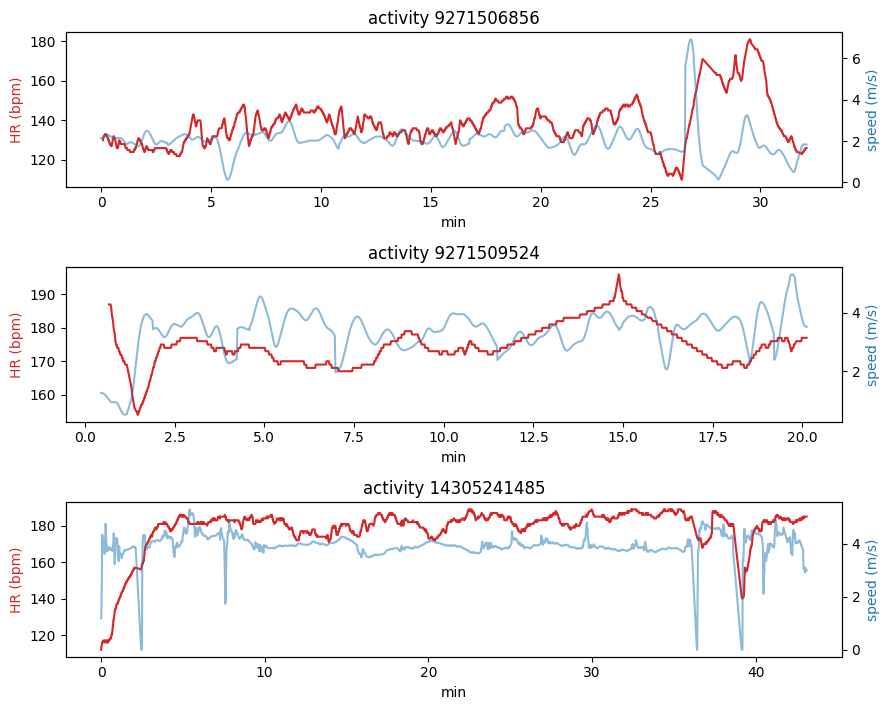

In [8]:
import matplotlib.pyplot as plt

sample_ids = (
    streams.drop_duplicates("activity_id")
    .query("source_format == 'fit'")["activity_id"]
    .sample(min(3, n_kept), random_state=0)
    .tolist()
)
fig, axes = plt.subplots(len(sample_ids), 1, figsize=(9, 2.4 * len(sample_ids)), sharex=False)
if len(sample_ids) == 1:
    axes = [axes]
for ax, aid in zip(axes, sample_ids):
    s = streams[streams["activity_id"] == aid]
    ax2 = ax.twinx()
    ax.plot(s["elapsed_s"] / 60, s["hr_bpm"], color="tab:red", label="HR")
    ax2.plot(s["elapsed_s"] / 60, s["speed_mps"], color="tab:blue", alpha=0.5, label="speed")
    ax.set_title(f"activity {aid}")
    ax.set_ylabel("HR (bpm)", color="tab:red")
    ax2.set_ylabel("speed (m/s)", color="tab:blue")
    ax.set_xlabel("min")
fig.tight_layout()

In [9]:
# Persist the kept summary (drop the abs_path column — non-portable; recompute from Filename if needed)
runs_out = runs.drop(columns=["abs_path"])
runs_out.to_parquet(DATA_DIR / "raw" / "activities_raw.parquet", index=False)
streams.to_parquet(DATA_DIR / "streams" / "streams.parquet", index=False)

print("Wrote:")
print(f"  {DATA_DIR/'raw'/'activities_raw.parquet'}  ({len(runs_out)} rows)")
print(f"  {DATA_DIR/'streams'/'streams.parquet'}  ({len(streams):,} rows)")

Wrote:
  /Users/as/Library/Mobile Documents/com~apple~CloudDocs/Dokumente/Studium/Master-26-FS/Big Data Methods for Economists/BDME/Project/data/raw/activities_raw.parquet  (482 rows)
  /Users/as/Library/Mobile Documents/com~apple~CloudDocs/Dokumente/Studium/Master-26-FS/Big Data Methods for Economists/BDME/Project/data/streams/streams.parquet  (1,348,656 rows)
